In [47]:
!pip install xgboost imbalanced-learn shap

Upload Dataset

In [48]:
import pandas as pd

df = pd.read_csv('/content/upi_fraud_dataset (1).csv')

df.head()

,Unnamed: 0,trans_hour,trans_day,trans_month,trans_year,category,upi_number,age,trans_amount,state,zip,fraud_risk
0,0,0,1,1,2022,12,9957000001,54,66.21,22,49879,0
1,1,1,1,1,2022,3,9957000002,15,55.81,14,62668,0
2,2,3,1,1,2022,8,9957000003,60,8.68,4,96037,0
3,3,6,1,1,2022,4,9957000004,44,89.52,40,29911,0
4,4,6,1,1,2022,0,9957000005,72,1.90,38,16421,0


Basic Cleaning

In [50]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_6002/3565136223.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [51]:
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [52]:
target = 'fraud_risk'   # changed from 'is_fraud' to 'fraud_risk'

X = df.drop(target, axis=1)
y = df[target]

Train-Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Train Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("OOB Score:", rf_model.oob_score_)

OOB Score: 0.9603803486529319


Train XGBoost

In [56]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

[0]	validation_0-auc:0.97910	validation_1-auc:0.97200
[50]	validation_0-auc:0.99727	validation_1-auc:0.99054
[100]	validation_0-auc:0.99856	validation_1-auc:0.99248
[150]	validation_0-auc:0.99919	validation_1-auc:0.99369
[200]	validation_0-auc:0.99955	validation_1-auc:0.99395
[250]	validation_0-auc:0.99978	validation_1-auc:0.99453
[300]	validation_0-auc:0.99988	validation_1-auc:0.99463
[350]	validation_0-auc:0.99994	validation_1-auc:0.99486
[400]	validation_0-auc:0.99998	validation_1-auc:0.99505
[450]	validation_0-auc:0.99999	validation_1-auc:0.99512
[499]	validation_0-auc:1.00000	validation_1-auc:0.99537


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [57]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [58]:
def evaluate(y_test, y_pred, y_prob, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [59]:
evaluate(y_test, rf_pred, rf_prob, "Random Forest")
evaluate(y_test, xgb_pred, xgb_prob, "XGBoost")


Random Forest
Accuracy: 0.9588014981273408
Precision: 0.9835526315789473
Recall: 0.9462025316455697
F1 Score: 0.964516129032258
ROC-AUC: 0.9917837649518058

XGBoost
Accuracy: 0.9644194756554307
Precision: 0.9837133550488599
Recall: 0.9556962025316456
F1 Score: 0.9695024077046549
ROC-AUC: 0.9953692950876786


Confusion Matrix

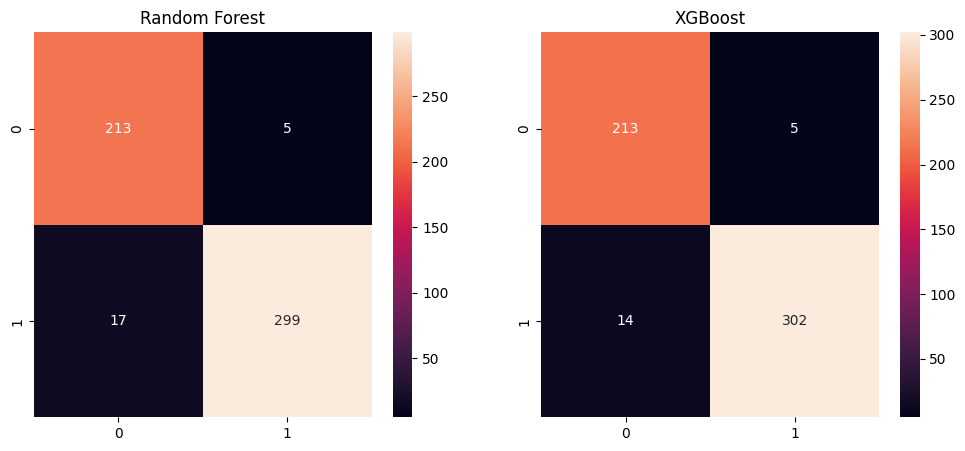

In [60]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Random Forest")

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("XGBoost")

plt.show()

ROC Curve Comparison

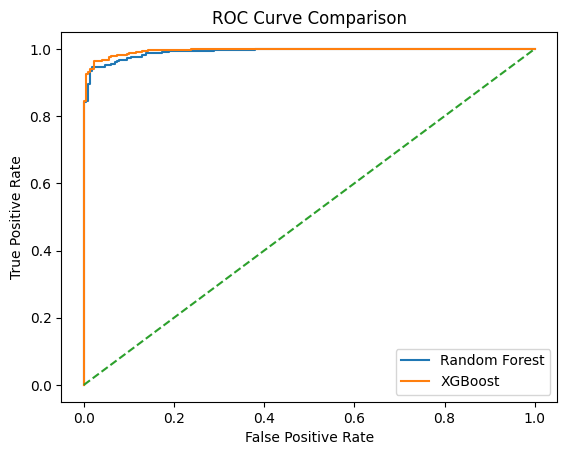

In [61]:
from sklearn.metrics import roc_curve

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

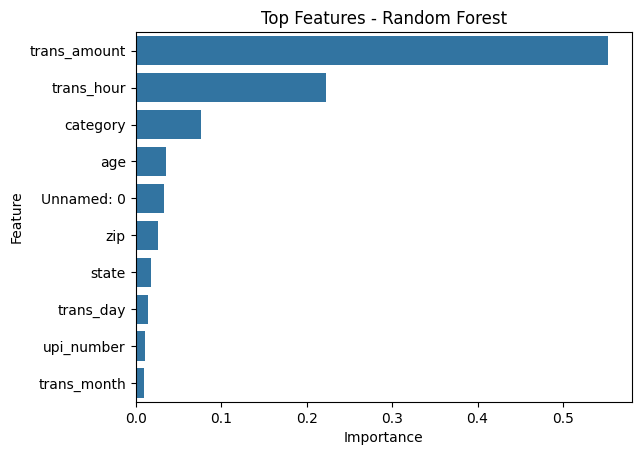

In [62]:
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Features - Random Forest")
plt.show()

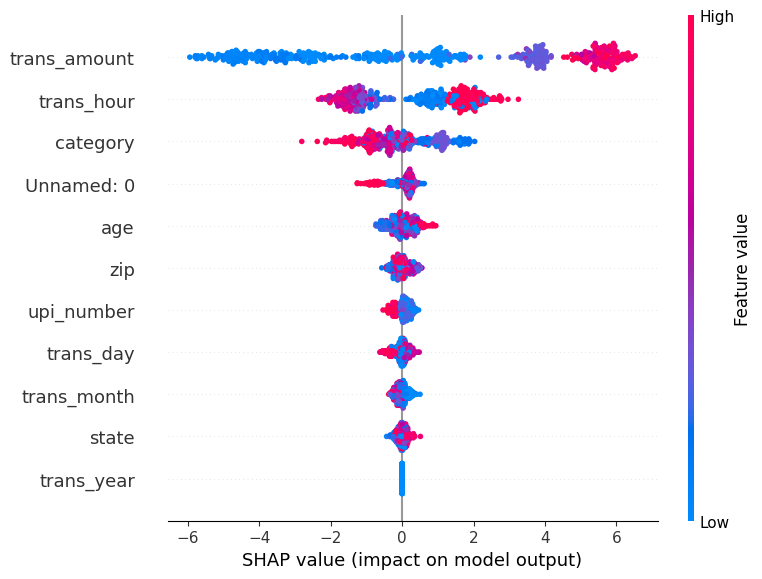

In [63]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [64]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']